In [ ]:
# Install necessary libraries
!pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of candidates to simulate
n_candidates = 100

# Fields based on your Courses.py
fields = ['Data Science & AI', 'Web Development', 'Cybersecurity', 'DevOps & Cloud', 'Product Management']
data = {
    'ID': range(1, n_candidates + 1),
    'Name': [f'Candidate {i}' for i in range(1, n_candidates + 1)],
    'Field': np.random.choice(fields, n_candidates),
    'Skills_Score': np.random.uniform(10, 40, n_candidates), # Max 40
    'Education_Score': np.random.uniform(10, 30, n_candidates), # Max 30
    'Experience_Score': np.random.uniform(5, 20, n_candidates), # Max 20
    'Semantic_Score': np.random.uniform(2, 10, n_candidates), # Max 10
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate Total Score based on your logic (sum of components)
df['Total_Score'] = df['Skills_Score'] + df['Education_Score'] + df['Experience_Score'] + df['Semantic_Score']

# Round for display
df = df.round(2)

# Display first few rows
print("Simulated Database Data:")
df.head()

Simulated Database Data:


,ID,Name,Field,Skills_Score,Education_Score,Experience_Score,Semantic_Score,Total_Score
0,1,Candidate 1,DevOps & Cloud,37.45,23.51,5.76,5.97,72.69
1,2,Candidate 2,Product Management,35.50,24.70,18.30,7.54,86.05
2,3,Candidate 3,Cybersecurity,23.48,14.18,5.41,4.79,47.87
3,4,Candidate 4,Product Management,12.86,20.83,13.68,9.49,56.87
4,5,Candidate 5,Product Management,21.12,23.92,11.58,2.31,58.93


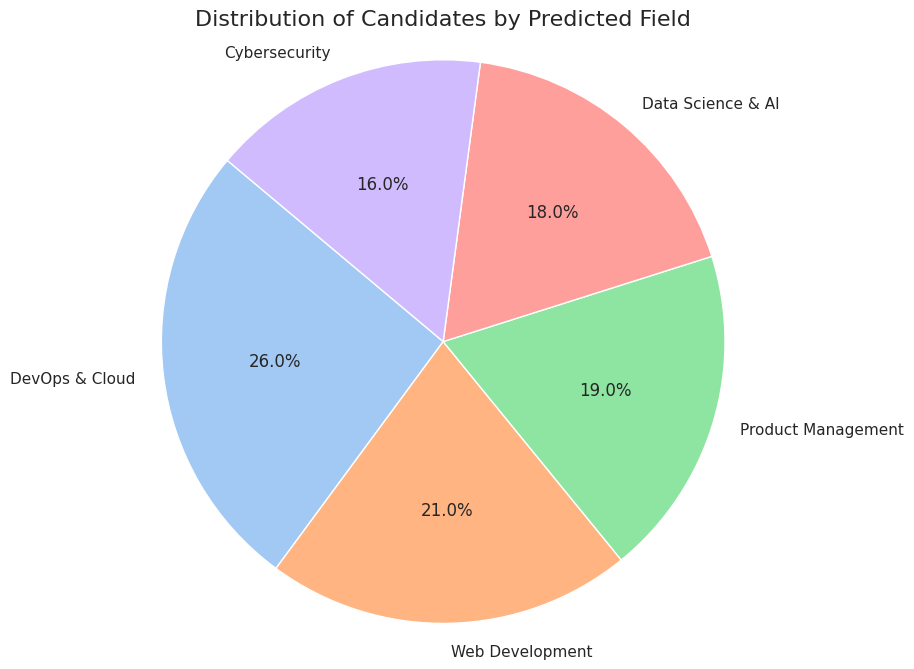

In [ ]:
# Count candidates per field
field_counts = df['Field'].value_counts()

# Define colors
colors = sns.color_palette('pastel')[0:len(field_counts)]

# Create Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(field_counts, labels=field_counts.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Distribution of Candidates by Predicted Field', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

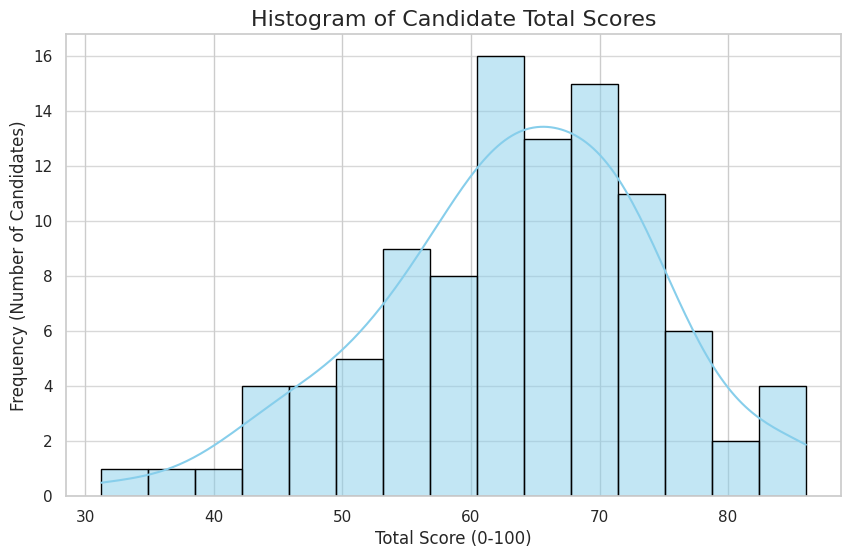

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_Score'], bins=15, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram of Candidate Total Scores', fontsize=16)
plt.xlabel('Total Score (0-100)', fontsize=12)
plt.ylabel('Frequency (Number of Candidates)', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

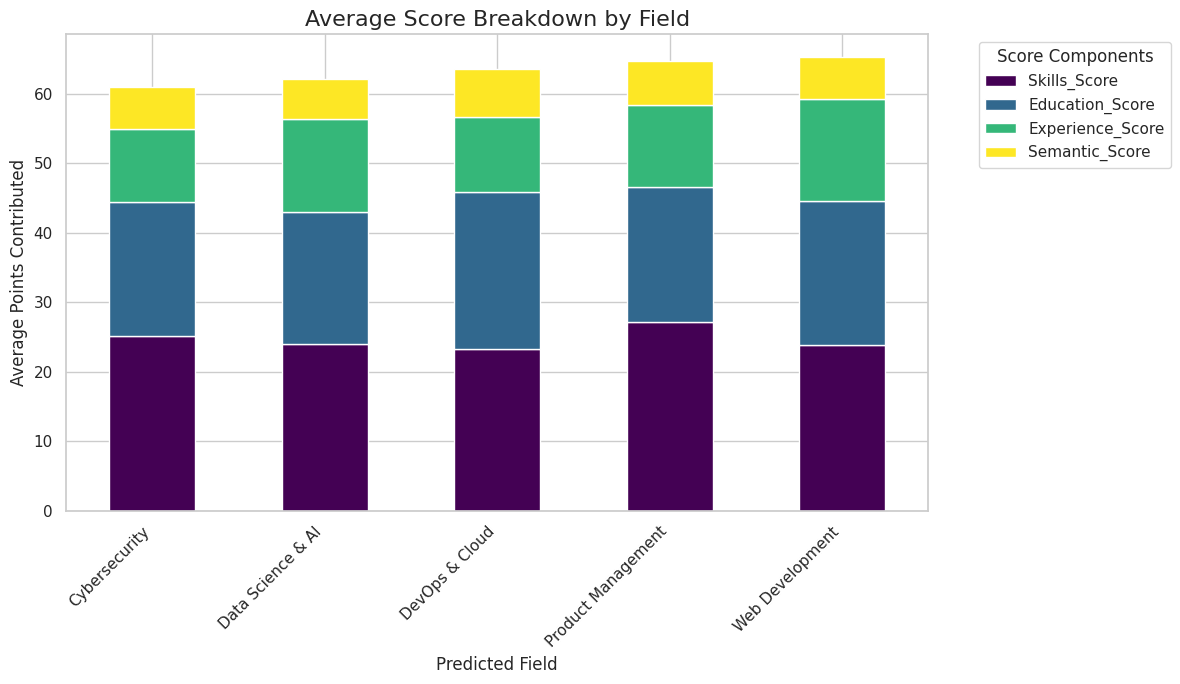

In [ ]:
# Group by Field and calculate mean for each score component
grouped_df = df.groupby('Field')[['Skills_Score', 'Education_Score', 'Experience_Score', 'Semantic_Score']].mean()

# Plot Stacked Bar Chart
ax = grouped_df.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Average Score Breakdown by Field', fontsize=16)
plt.ylabel('Average Points Contributed', fontsize=12)
plt.xlabel('Predicted Field', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Score Components", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

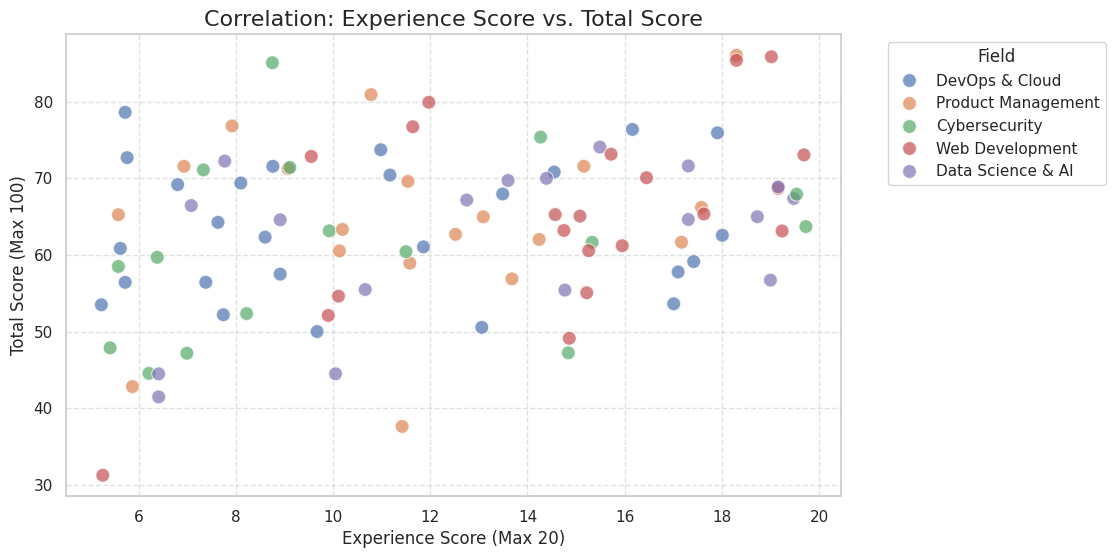

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Experience_Score', y='Total_Score', hue='Field', s=100, alpha=0.7)

plt.title('Correlation: Experience Score vs. Total Score', fontsize=16)
plt.xlabel('Experience Score (Max 20)', fontsize=12)
plt.ylabel('Total Score (Max 100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()